In [7]:
from typing import Dict, TypedDict
from langgraph.graph import StateGraph, START, END

In [8]:
class AgentState(TypedDict):
    number1: int
    operation: str
    number2: int
    number3: int
    operation2: str
    number4: int
    finalnumber: int
    finalnumber2: int


def addition_node1(state: AgentState) -> AgentState:
    """This the first addition node"""
    state["finalnumber"] = state["number1"] + state["number2"]
    return state

def subtract_node1(state: AgentState) -> AgentState:
    """This the first subtraction node"""
    state["finalnumber"] = state["number1"] - state["number2"]
    return state

def addition_node2(state: AgentState) -> AgentState:
    """This the second addition node"""
    state["finalnumber2"] = state["number3"] + state["number4"]
    return state

def subtract_node2(state: AgentState) -> AgentState:
    """This the second subtraction node"""
    state["finalnumber2"] = state["number3"] - state["number4"]
    return state

def decider_node1(state:AgentState) -> AgentState:
    """This is the decider or router node for the first operation"""
    if state["operation"] == "+":
        return "addition_operation"
    elif state["operation"] == "-":
        return "subtraction_operation"
        
def decider_node2(state:AgentState) -> AgentState:
    """This is the decider or router node for the second operation"""
    if state["operation2"] == "+":
        return "addition_operation2"
    elif state["operation2"] == "-":
        return "subtraction_operation2"

In [9]:
graph = StateGraph(AgentState)
graph.add_node("addition_node1", addition_node1)
graph.add_node("subtract_node1", subtract_node1)
graph.add_node("router", lambda state:state)

graph.add_node("addition_node2", addition_node2)
graph.add_node("subtract_node2", subtract_node2)
graph.add_node("router2", lambda state:state)

graph.add_edge(START, "router")

graph.add_conditional_edges(
    "router",
    decider_node1, 

    {
        # Edge: Node
        "addition_operation": "addition_node1",
        "subtraction_operation": "subtract_node1"
    }

)

graph.add_edge("addition_node1", "router2")
graph.add_edge("subtract_node1", "router2")

graph.add_conditional_edges(
    "router2",
    decider_node2, 

    {
        # Edge: Node
        "addition_operation2": "addition_node2",
        "subtraction_operation2": "subtract_node2"
    }

)

graph.add_edge("addition_node2", END)
graph.add_edge("subtract_node2", END)

app = graph.compile()


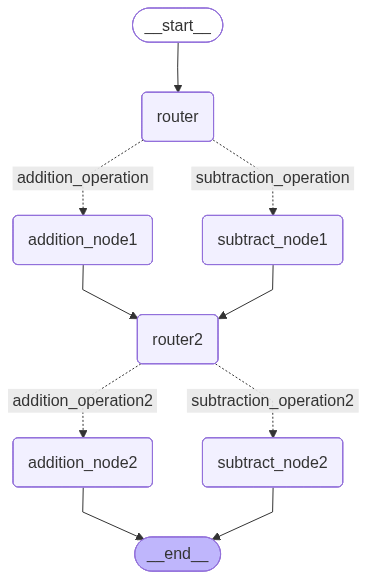

In [10]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [12]:
res_store = AgentState(number1 = 10, operation="+", number2 = 5,number3 = 10, operation2="-", number4 = 8)
print(app.invoke(res_store))

{'number1': 10, 'operation': '+', 'number2': 5, 'number3': 10, 'operation2': '-', 'number4': 8, 'finalnumber': 15, 'finalnumber2': 2}
